In [16]:
import numpy as np

def random_boundary_site(L, rng):
    """Choose a random point on one of the four boundaries."""
    side = rng.integers(4)
    s = rng.integers(L)
    if side == 0:
        return 0, s
    elif side == 1:
        return L - 1, s
    elif side == 2:
        return s, 0
    else:
        return s, L - 1


def touches_cluster(cluster, x, y):
    """Check the four nearest neighbours with periodic boundaries."""
    L = cluster.shape[0]
    return ( cluster[(x + 1) % L, y] or cluster[(x - 1) % L, y] or cluster[x, (y + 1) % L] or cluster[x, (y - 1) % L])

def grow_dla(L=40):
    """Grow a DLA cluster until it first reaches an edge."""
    rng = np.random.default_rng()
    cluster = np.zeros((L, L), dtype=bool)
    center = L // 2
    cluster[center, center] = True
    masses = []
    radii = []
    while True:
        x, y = random_boundary_site(L, rng)
        # Random walk until the particle touches the cluster.
        while not touches_cluster(cluster, x, y):
            step = rng.integers(4)
            if step == 0:
                x = (x + 1) % L
            elif step == 1:
                x = (x - 1) % L
            elif step == 2:
                y = (y + 1) % L
            else:
                y = (y - 1) % L
        # The particle sticks.
        cluster[x, y] = True
        # Stop when the cluster reaches a boundary.
        if x == 0 or x == L - 1 or y == 0 or y == L - 1:
            break
    return cluster

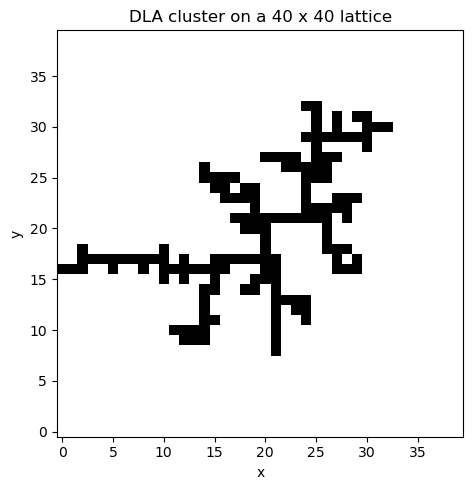

Final cluster mass: 152


In [17]:
cluster = grow_dla(L=40)

plt.figure(figsize=(5, 5))
plt.imshow(cluster, origin='lower', cmap='binary')
plt.title('DLA cluster on a 40 x 40 lattice')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

print('Final cluster mass:', cluster.sum())